# Validation Set Evaluation
Runs demucs -> tab CRNN pipeline over clean synthetic MusDB18 + Guitarset mix dataset
Used to determine benchmark of the pipeline in a best case senario (clean mixes, guitar styles that it was trained on)

Dataset Dir:
guitarset_demucs/guitarset_mixes_dataset_clean/val/`.

In [1]:
import sys, os
from pathlib import Path

REPO_ROOT = Path(os.getcwd())
SRC_DIR   = REPO_ROOT / 'src'
for p in [str(REPO_ROOT), str(SRC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

In [2]:
import torch
import numpy as np
import jams
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config
from src.run_pipeline import PipelineState, Node, run_pipeline
from src.nodes import stem_extraction, load_model, predict
from evaluation.metrics import calculate_note_level_metrics, calculate_onset_event_metrics

In [3]:
# ── Configuration ──────────────────────────────────────────────────────────────
VAL_DIR       = REPO_ROOT / 'guitarset_demucs' / 'guitarset_mixed_dataset_clean' / 'val'
ARTIFACTS_DIR = REPO_ROOT / 'hyperparam_set_v1'
ONSET_THRESH  = config.DEFAULT_TDR_THRESHOLD   # 0.5

# Auto-detect device
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

# Open-string MIDI pitches: string 0 = low E (40), ..., string 5 = high e (64)
OPEN_STRING_PITCHES = config.OPEN_STRING_PITCHES_MIDI  # {0:40,1:45,2:50,3:55,4:59,5:64}

Device: mps


In [4]:
# ── Select model run ───────────────────────────────────────────────────────────
runs = sorted([d for d in ARTIFACTS_DIR.iterdir()
               if d.is_dir() and (d / 'best_model.pth').exists()])

print('Available runs:')
for i, r in enumerate(runs):
    print(f'  [{i}] {r.name}')

Available runs:
  [0] run_4_Baseline_run72_re-run_with_new_aug_augEnabled
  [1] run_5_Test_Higher_Dropout_0.55_augEnabled
  [2] run_6_Test_More_Patient_Scheduler_12_augEnabled
  [3] run_7_Test_Higher_OnsetLossWeight_10_augEnabled
  [4] run_8_Test_Higher_Dropout_and_Patient_Scheduler_augEnabled


In [5]:
RUN_IDX = 3   # ← change this to select a different run

run_dir = runs[RUN_IDX]
print(f'Loading: {run_dir.name}')

# Build a state just to load the model once — reused for all tracks
_init_state = PipelineState(
    input_path=Path('/dev/null'),
    artifacts_dir=ARTIFACTS_DIR,
    extras={'device': DEVICE, 'run_name': run_dir.name},
)
_init_state = load_model(_init_state)
shared_model = _init_state.model
print('Model loaded.')

Loading: run_7_Test_Higher_OnsetLossWeight_10_augEnabled
--- Próba załadowania modelu z pliku: best_model.pth ---
Odtworzone parametry inicjalizacyjne: {'num_frames_rnn_input_dim': 1280, 'rnn_type': 'GRU', 'rnn_hidden_size': 768, 'rnn_layers': 2, 'rnn_dropout': 0.5, 'rnn_bidirectional': True}
Ładowanie wag na urządzenie: mps
Model pomyślnie załadowany i przeniesiony na urządzenie: mps
Model loaded.


In [6]:
def parse_gt_notes_from_jams(jams_path):
    """Return list of GT note dicts from a GuitarSet JAMS file.
    Each annotation in note_midi corresponds to one string (index 0-5).
    obs.time and obs.duration are plain floats (seconds).
    """
    j = jams.load(str(jams_path))
    note_anns = j.search(namespace='note_midi')
    notes = []
    for string_idx, ann in enumerate(note_anns):
        open_pitch = OPEN_STRING_PITCHES[string_idx]
        for obs in ann.data:
            pitch = int(round(obs.value))
            fret  = pitch - open_pitch
            if 0 <= fret <= config.MAX_FRETS:
                notes.append({
                    'start_time': float(obs.time),
                    'end_time':   float(obs.time + obs.duration),
                    'pitch_midi': pitch,
                    'string':     string_idx,
                    'fret':       fret,
                })
    return notes

In [7]:
def gt_notes_to_raw_tensor(gt_notes):
    """Convert GT note list to the (N,4) tensor format expected by metrics.py."""
    if not gt_notes:
        return torch.zeros((0, 4))
    rows = [[n['start_time'], n['end_time'], n['string'], n['fret']] for n in gt_notes]
    return torch.tensor(rows, dtype=torch.float32)

In [8]:
# ── Run evaluation over all val tracks ────────────────────────────────────────
PIPELINE_NODES = [
    Node("stem_extraction", stem_extraction),
    Node("predict",         predict),
]

wav_files = sorted(VAL_DIR.glob('*.wav'))
print(f'Evaluating {len(wav_files)} tracks...')

results = []

for wav_path in tqdm(wav_files):
    track_id  = wav_path.stem
    jams_path = wav_path.with_suffix('.jams')

    if not jams_path.exists():
        print(f'  [SKIP] No JAMS for {track_id}')
        continue

    try:
        state = PipelineState(
            input_path=wav_path,
            artifacts_dir=ARTIFACTS_DIR,
            model=shared_model,   # reuse loaded model — no reload per track
            extras={'device': DEVICE, 'run_name': run_dir.name},
        )
        state = run_pipeline(state, PIPELINE_NODES)

        pred_notes = state.predicted_notes or []
        gt_notes   = parse_gt_notes_from_jams(jams_path)
        gt_raw     = gt_notes_to_raw_tensor(gt_notes)

        tdr   = calculate_note_level_metrics(pred_notes, gt_raw)
        onset = calculate_onset_event_metrics(pred_notes, gt_raw)

        results.append({
            'track':           track_id,
            'n_gt_notes':      len(gt_notes),
            'n_pred_notes':    len(pred_notes),
            'tdr_precision':   tdr['tdr_precision'],
            'tdr_recall':      tdr['tdr_recall'],
            'tdr_f1':          tdr['tdr_f1'],
            'onset_precision': onset['onset_precision_event'],
            'onset_recall':    onset['onset_recall_event'],
            'onset_f1':        onset['onset_f1_event'],
        })

    except Exception as e:
        print(f'  [ERROR] {track_id}: {e}')

df = pd.DataFrame(results)
print(f'\nDone. {len(df)} tracks evaluated.')

Evaluating 72 tracks...


  0%|          | 0/72 [00:00<?, ?it/s]

INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Loading model: htdemucs_6s


[RUN]  stem_extraction


INFO:stem_extraction:Separating stems for: 00_BN1-147-Gb_solo.wav
INFO:stem_extraction:Stem saved to: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/00_BN1-147-Gb_solo.wav


...

[RUN]  predict


INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Loading model: htdemucs_6s


[RUN]  stem_extraction


INFO:stem_extraction:Separating stems for: 05_SS2-107-Ab_comp.wav
INFO:stem_extraction:Stem saved to: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/05_SS2-107-Ab_comp.wav


[RUN]  predict

Done. 72 tracks evaluated.


In [9]:
# ── Summary statistics ─────────────────────────────────────────────────────────
metric_cols = ['tdr_precision','tdr_recall','tdr_f1','onset_precision','onset_recall','onset_f1']
summary = df[metric_cols].agg(['mean','median','std']).T
summary.columns = ['mean','median','std']
print(f'Run: {run_dir.name}\n')
print(summary.to_string(float_format='{:.3f}'.format))

Run: run_7_Test_Higher_OnsetLossWeight_10_augEnabled

                 mean  median   std
tdr_precision   0.752   0.780 0.159
tdr_recall      0.707   0.787 0.224
tdr_f1          0.716   0.785 0.198
onset_precision 0.862   0.901 0.133
onset_recall    0.633   0.664 0.247
onset_f1        0.705   0.747 0.206


In [10]:
# ── Per-track table ────────────────────────────────────────────────────────────
df.set_index('track')[metric_cols].sort_values('tdr_f1', ascending=False).style.format('{:.3f}').background_gradient(cmap='RdYlGn', axis=0)

,tdr_precision,tdr_recall,tdr_f1,onset_precision,onset_recall,onset_f1
track,,,,,,
03_BN1-129-Eb_solo,0.932,0.948,0.940,0.983,0.983,0.983
01_Rock1-90-C#_comp,0.887,0.958,0.922,0.976,0.569,0.719
02_BN2-131-B_solo,0.909,0.909,0.909,0.955,0.955,0.955
03_Funk1-114-Ab_solo,0.944,0.875,0.908,0.966,0.885,0.924
05_Jazz1-200-B_solo,0.936,0.880,0.907,0.936,0.880,0.907
05_BN1-129-Eb_solo,0.929,0.886,0.907,0.952,0.909,0.930
04_Rock1-90-C#_solo,0.929,0.878,0.903,0.957,0.892,0.923
04_Rock3-148-C_solo,0.878,0.915,0.897,0.890,0.915,0.903
01_Rock2-142-D_solo,0.873,0.904,0.888,0.924,0.956,0.940


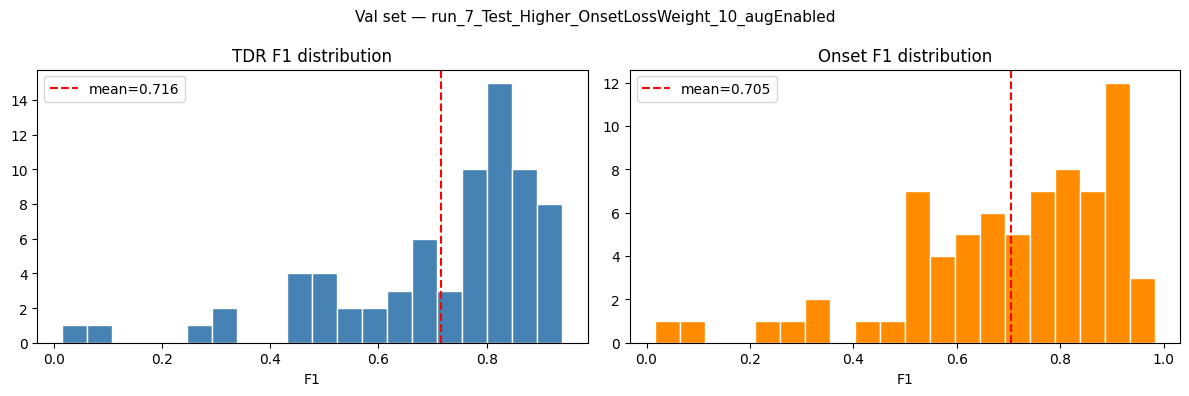

In [11]:
# ── Distribution plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Val set — {run_dir.name}', fontsize=11)

axes[0].hist(df['tdr_f1'],    bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df['tdr_f1'].mean(), color='red', linestyle='--', label=f'mean={df["tdr_f1"].mean():.3f}')
axes[0].set_title('TDR F1 distribution')
axes[0].set_xlabel('F1'); axes[0].legend()

axes[1].hist(df['onset_f1'], bins=20, color='darkorange', edgecolor='white')
axes[1].axvline(df['onset_f1'].mean(), color='red', linestyle='--', label=f'mean={df["onset_f1"].mean():.3f}')
axes[1].set_title('Onset F1 distribution')
axes[1].set_xlabel('F1'); axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# ── Best and worst tracks ──────────────────────────────────────────────────────
n = 5
print(f'Top {n} tracks (TDR F1):')
print(df.nlargest(n, 'tdr_f1')[['track','tdr_f1','onset_f1','n_gt_notes']].to_string(index=False))
print(f'\nBottom {n} tracks (TDR F1):')
print(df.nsmallest(n, 'tdr_f1')[['track','tdr_f1','onset_f1','n_gt_notes']].to_string(index=False))

Top 5 tracks (TDR F1):
               track   tdr_f1  onset_f1  n_gt_notes
  03_BN1-129-Eb_solo 0.940171  0.982759          58
 01_Rock1-90-C#_comp 0.921536  0.719298         288
   02_BN2-131-B_solo 0.909091  0.954545          66
03_Funk1-114-Ab_solo 0.908108  0.923913          96
 05_Jazz1-200-B_solo 0.907216  0.907216          50

Bottom 5 tracks (TDR F1):
               track   tdr_f1  onset_f1  n_gt_notes
  02_SS2-107-Ab_comp 0.015748  0.016064         235
    02_SS2-88-F_comp 0.095238  0.106870         241
02_Funk3-112-C#_comp 0.272000  0.252101         200
  02_Funk3-98-A_comp 0.294416  0.293478         130
  00_BN1-147-Gb_solo 0.296875  0.412698          89
